In [7]:
import pandas as pd

data_path = "../data/raw/ethiopia_fi_unified_data.xlsx"
xl_file = pd.ExcelFile(data_path)

# This will print the exact available sheet names in your file
print("Available sheets:", xl_file.sheet_names)

Available sheets: ['ethiopia_fi_unified_data', 'Impact_sheet']


In [10]:
print(impact_model_df.columns.tolist())

['record_id_link', 'parent_id', 'record_type_link', 'category_link', 'pillar_link', 'indicator_link', 'indicator_code_link', 'indicator_direction_link', 'value_numeric_link', 'value_text_link', 'value_type_link', 'unit_link', 'observation_date_link', 'period_start_link', 'period_end_link', 'fiscal_year_link', 'gender_link', 'location_link', 'region_link', 'source_name_link', 'source_type_link', 'source_url_link', 'confidence_link', 'related_indicator_link', 'relationship_type_link', 'impact_direction_link', 'impact_magnitude_link', 'impact_estimate_link', 'lag_months_link', 'evidence_basis_link', 'comparable_country_link', 'collected_by_link', 'collection_date_link', 'original_text_link', 'notes_link', 'record_id_event', 'record_type_event', 'category_event', 'pillar_event', 'indicator_event', 'indicator_code_event', 'indicator_direction_event', 'value_numeric_event', 'value_text_event', 'value_type_event', 'unit_event', 'observation_date_event', 'period_start_event', 'period_end_event


--- Event-Indicator Association Matrix ---


C:\Users\HP\AppData\Local\Temp\ipykernel_14804\764180826.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  impact_model_df['impact_val'] = impact_model_df['impact_magnitude_link'].replace(impact_mapping)


related_indicator_link,ACC_4G_COV,ACC_MM_ACCOUNT,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_TELEBIRR_USERS
parent_id,,,,,,,,,
EVT_0001,0.0,0.0,3.0,0.0,0.0,0.0,0.0,3.0,3.0
EVT_0002,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
EVT_0003,0.0,2.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0
EVT_0004,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0
EVT_0005,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
EVT_0007,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0
EVT_0008,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
EVT_0010,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


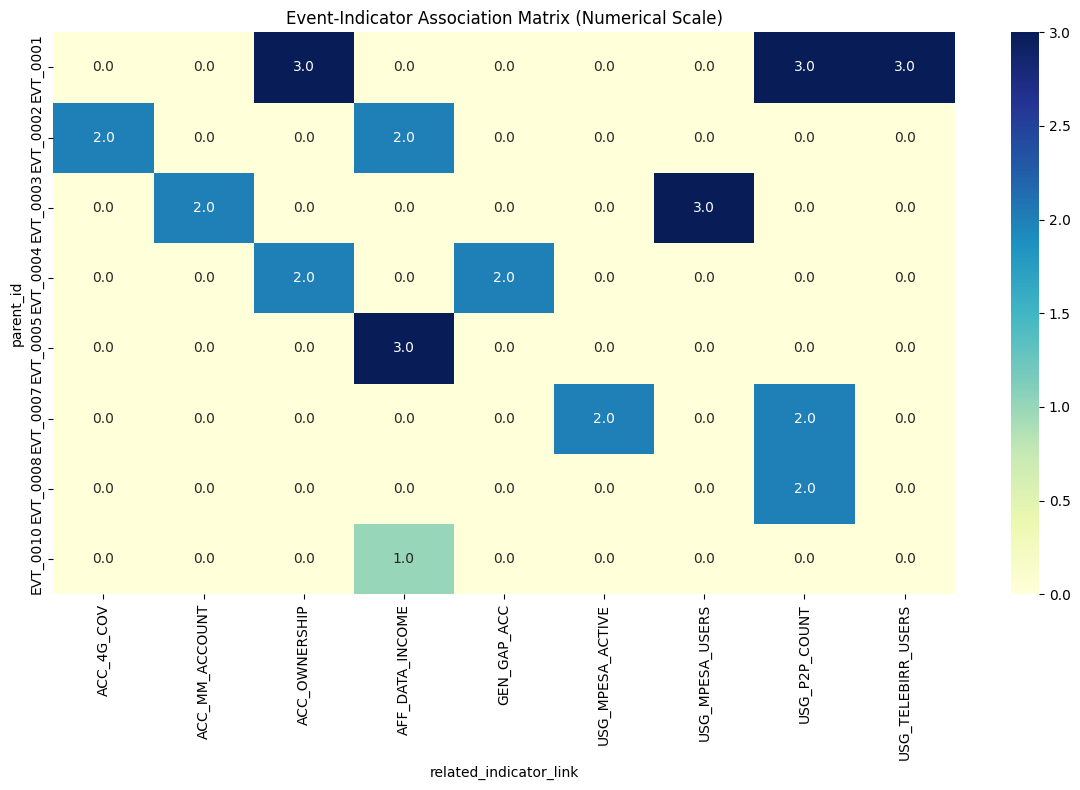

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load the enriched dataset
data_path = "../data/raw/ethiopia_fi_unified_data.xlsx"
df_data = pd.read_excel(data_path, sheet_name="ethiopia_fi_unified_data")
df_links = pd.read_excel(data_path, sheet_name="Impact_sheet")

# 2. Filter events and join
events_df = df_data[df_data["record_type"] == "event"].copy()
impact_model_df = df_links.merge(
    events_df, 
    left_on="parent_id", 
    right_on="record_id", 
    suffixes=("_link", "_event")
)

# 3. Convert impact_magnitude_link to numeric scale for plotting
# Mapping categorical strings to numbers
impact_mapping = {'low': 1.0, 'medium': 2.0, 'high': 3.0}
impact_model_df['impact_val'] = impact_model_df['impact_magnitude_link'].replace(impact_mapping)

# 4. Create Summary Association Matrix
# Using 'impact_val' (the numeric column) for the heatmap values
association_matrix = impact_model_df.pivot_table(
    index="parent_id", 
    columns="related_indicator_link", 
    values="impact_val", 
    aggfunc="first"
).fillna(0.0)

print("\n--- Event-Indicator Association Matrix ---")
display(association_matrix)

# 5. Visualization: Export Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(association_matrix, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title("Event-Indicator Association Matrix (Numerical Scale)")
plt.tight_layout()

# Save the plot
plt.savefig("../reports/figures/event_indicator_matrix.png")
plt.show()

In [16]:
def project_impact(event_id, start_date, horizon_months=12):
    """
    Predicts indicator change over time for a given event.
    Models the effect as: Magnitude * Function(time)
    """
    # 1. Retrieve the event impact profile from your association matrix
    event_row = association_matrix.loc[event_id]
    
    # 2. Define the temporal decay/growth function
    # For 'immediate' events, impact is flat. 
    # For 'gradual' (infrastructure), we use a simple linear ramp-up.
    t = np.arange(horizon_months)
    
    projections = {}
    for indicator, magnitude in event_row.items():
        if magnitude == 0: continue
        
        # Modeling logic: Effect starts after 'lag_months'
        # lag = impact_model_df.loc[event_id, 'lag_months_link'] 
        
        # Simple Linear Ramp-up model
        effect = (magnitude / horizon_months) * t
        projections[indicator] = effect
        
    return pd.DataFrame(projections)

